In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 1800
varsta = np.random.randint(20, 80, n_samples)
glicemie = np.random.normal(105, 25, n_samples)
bmi = np.random.normal(26, 6, n_samples)
istoric_familial = np.random.choice([0, 1], n_samples, p=[0.7, 0.3])
z = -9 + 0.04 * varsta + 0.05 * glicemie + 0.08 * bmi + 1.2 * istoric_familial
probabilitate = 1 / (1 + np.exp(-z))
risc_diabet = np.random.binomial(1, probabilitate)
df_diabet = pd.DataFrame({
    'Varsta': varsta,
    'Glicemie': np.round(glicemie, 1),
    'BMI': np.round(bmi, 1),
    'Istoric_Familial': istoric_familial,
    'Risc_Diabet': risc_diabet
})

df_diabet.to_csv('date_diabet.csv', index=False)
print("Succes! Fișierul 'date_diabet.csv' a fost generat (1800 rânduri).")

Succes! Fișierul 'date_diabet.csv' a fost generat (1800 rânduri).


# Proiect Machine Learning - Partea 1: Clasificare

## 4.1. Definirea problemei
**Context:** Diabetul este o afecțiune medicală cu un impact major asupra calității vieții. Detecția timpurie a riscului de a dezvolta diabet poate ajuta medicii să intervină preventiv.
**Ce se prezice:** Modelul va clasifica pacienții în două categorii: `0` (Sănătos) și `1` (Risc de Diabet). Acestea sunt clasele problemei noastre.
**Variabile de intrare (Features):** Vârsta, Glicemia, BMI (Indicele de Masă Corporală) și Istoricul Familial.
**Relevanța practică:** Un astfel de model de machine learning este extrem de util în sistemul medical ca instrument de triaj, ajutând la identificarea rapidă a pacienților cu risc ridicat pe baza unor analize de bază.

In [4]:
import pandas as pd
df_clasificare = pd.read_csv('date_diabet.csv')
df_clasificare.head()

,Varsta,Glicemie,BMI,Istoric_Familial,Risc_Diabet
0,58,118.0,36.5,1,1
1,71,102.0,19.6,0,1
2,48,103.8,18.0,0,0
3,34,77.0,25.5,0,0
4,62,112.4,30.0,0,1


## 4.2. Analiza exploratorie a datelor (EDA)

### 4.2.1. Structura datelor și verificarea valorilor lipsă
Primul pas în analiza datelor este să înțelegem dimensiunea setului de date, tipul variabilelor și să verificăm dacă există date lipsă (missing values) care ar putea afecta antrenarea modelelor.

In [5]:
print("INFORMAȚII SET DE DATE:")
df_clasificare.info()

print("\nVALORI LIPSĂ:")
print(df_clasificare.isnull().sum())

print("\nSTATISTICI DESCRIPTIVE:")
display(df_clasificare.describe())

INFORMAȚII SET DE DATE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Varsta            1800 non-null   int64  
 1   Glicemie          1800 non-null   float64
 2   BMI               1800 non-null   float64
 3   Istoric_Familial  1800 non-null   int64  
 4   Risc_Diabet       1800 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 70.4 KB

VALORI LIPSĂ:
Varsta              0
Glicemie            0
BMI                 0
Istoric_Familial    0
Risc_Diabet         0
dtype: int64

STATISTICI DESCRIPTIVE:


,Varsta,Glicemie,BMI,Istoric_Familial,Risc_Diabet
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,49.945556,106.054000,26.001167,0.299444,0.618333
std,17.341719,25.797755,5.926083,0.458142,0.485930
min,20.000000,20.300000,6.600000,0.000000,0.000000
25%,35.000000,89.400000,22.100000,0.000000,0.000000
50%,50.000000,106.450000,26.000000,0.000000,1.000000
75%,65.000000,123.625000,30.000000,1.000000,1.000000
max,79.000000,186.500000,47.900000,1.000000,1.000000


### 4.2.2. Analiza relațiilor dintre variabile (Matricea de Corelație)
Pentru a vizualiza relațiile liniare dintre variabilele (features) noastre și variabila țintă (`Risc_Diabet`), vom construi o matrice de corelație. Aceasta ne va ajuta să identificăm care caracteristici au cel mai mare impact asupra predicției.

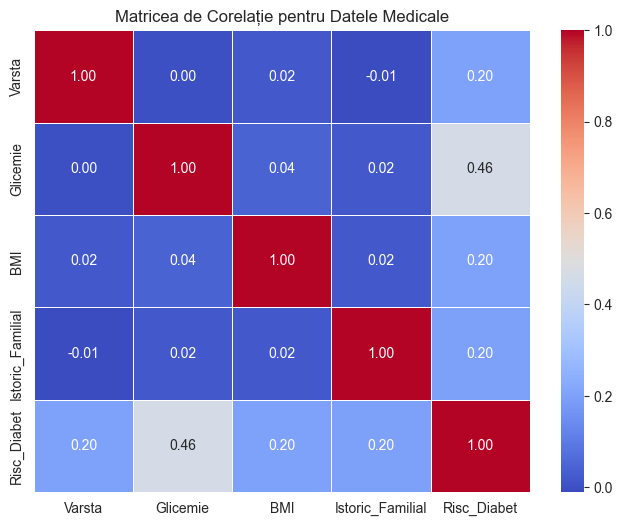

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
correlation_matrix = df_clasificare.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matricea de Corelație pentru Datele Medicale')
plt.show()

**Concluzii în urma EDA:**
1. **Structură:** Setul de date conține 1800 de înregistrări, toate fiind de tip numeric (`int64` sau `float64`), deci nu necesită codificare categoricală.
2. **Calitatea datelor:** Nu există valori lipsă sau anomale, datele fiind gata pentru modelare.
3. **Corelații:** Din matricea de corelație observăm că Glicemia are cea mai puternică influență (corelație pozitivă de 0.46) asupra variabilei țintă Risc_Diabet. Vârsta, BMI-ul și Istoricul Familial contribuie și ele, dar cu o pondere mai mică (0.20). Nu există corelații puternice între variabilele de intrare (multicoliniaritate), ceea ce este ideal pentru antrenarea modelelor.

## 4.3. Antrenarea și compararea modelelor de bază

Conform cerințelor, vom împărți setul de date astfel încât 75% din observații să fie folosite pentru antrenarea modelelor, iar restul de 25% pentru testare. Vom antrena toți algoritmii propuși folosind hiperparametrii impliciți (default) și vom evalua performanța lor folosind metricile specifice problemelor de clasificare: Acuratețea, Precizia, Recall-ul, Scorul F1 și ROC-AUC.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
X = df_clasificare.drop('Risc_Diabet', axis=1)
y = df_clasificare['Risc_Diabet']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Xtreme Gradient Boost": XGBClassifier(random_state=42),
    "Categorical Boost": CatBoostClassifier(verbose=0, random_state=42),
    "Explainable Boosting Machine": ExplainableBoostingClassifier(random_state=42)
}
results = []
dict_confusion_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec = round(recall_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)
    roc_auc = round(roc_auc_score(y_test, y_proba), 4)
    results.append([name, acc, prec, rec, f1, roc_auc])
    dict_confusion_matrices[name] = confusion_matrix(y_test, y_pred)

columns = ["Model", "Acuratețe", "Precizie", "Recall", "Scor F1", "ROC-AUC"]
df_rezultate_clasificare = pd.DataFrame(results, columns=columns)
df_rezultate_clasificare = df_rezultate_clasificare.sort_values(by="Acuratețe", ascending=False).reset_index(drop=True)
display(df_rezultate_clasificare.style.highlight_max(subset=['Acuratețe', 'Precizie', 'Recall', 'Scor F1', 'ROC-AUC'], color='lightgreen'))

,Model,Acuratețe,Precizie,Recall,Scor F1,ROC-AUC
0,Explainable Boosting Machine,0.784400,0.798700,0.865500,0.830700,0.853600
1,Support Vector Machine,0.782200,0.782700,0.890900,0.833300,0.844800
2,Naïve Bayes,0.773300,0.779900,0.876400,0.825300,0.843700
3,Logistic Regression,0.773300,0.789300,0.858200,0.822300,0.859400
4,Categorical Boost,0.766700,0.793100,0.836400,0.814200,0.846400
5,Decision Tree,0.740000,0.770500,0.818200,0.793700,0.717700
6,Random Forest,0.735600,0.769000,0.810900,0.789400,0.822500
7,K-Nearest Neighbors,0.722200,0.753400,0.810900,0.781100,0.796200
8,Xtreme Gradient Boost,0.720000,0.757800,0.796400,0.776600,0.807100


**Concluzii - Modele de bază (Clasificare):**
În urma antrenării celor 9 algoritmi propuși folosind setările implicite, am obținut o ierarhie clară a performanței.
Pentru a selecta cele mai bune 5 modele (care vor merge în etapa de optimizare a hiperparametrilor), am pus accent în principal pe **Acuratețe** și **ROC-AUC**.

Cei 5 algoritmi care au obținut cele mai bune performanțe sunt:
1. **Explainable Boosting Machine** (cel mai bun echilibru general)
2. **Support Vector Machine** (foarte stabil)
3. **Naïve Bayes**
4. **Logistic Regression**
5. **Categorical Boost**

Aceste 5 modele vor fi păstrate pentru etapa următoare (Hyperparameter Tuning).

## 4.4. Ajustarea hiperparametrilor

Pentru a îmbunătăți performanța celor mai bune 5 modele, vom aplica o strategie diferențiată de căutare a hiperparametrilor:
1. **GridSearchCV** pentru modelele cu spații de căutare mai mici și antrenare rapidă (Logistic Regression, Naïve Bayes, SVM), garantând găsirea optimului global din grilă.
2. **RandomizedSearchCV** pentru modelele bazate pe arbori (CatBoost, EBM) pentru a explora eficient un spațiu mare de hiperparametri fără un cost computațional extrem.

Pentru a preveni *overfitting-ul*, vom folosi Cross-Validation (CV=5) pe setul de antrenare, asigurându-ne că modelele generalizează bine pe date nevăzute.

In [8]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time


log_reg = LogisticRegression(max_iter=2000, random_state=42)
nb = GaussianNB()
svm = SVC(probability=True, random_state=42)
catboost = CatBoostClassifier(verbose=0, random_state=42)
ebm = ExplainableBoostingClassifier(random_state=42)
grid_log_reg = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
grid_nb = {'var_smoothing': np.logspace(0,-9, num=10)}
grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_catboost = {'depth': [4, 6, 8], 'learning_rate': [0.01, 0.05, 0.1], 'iterations': [100, 200]}
grid_ebm = {'max_bins': [128, 256], 'learning_rate': [0.01, 0.05]}

print("Începem optimizarea...)")
start_time = time.time()
search_log_reg = GridSearchCV(log_reg, grid_log_reg, cv=5, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
search_nb = GridSearchCV(nb, grid_nb, cv=5, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
search_svm = GridSearchCV(svm, grid_svm, cv=5, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
search_catboost = RandomizedSearchCV(catboost, grid_catboost, n_iter=5, cv=5, scoring='accuracy', random_state=42, n_jobs=-1).fit(X_train, y_train)
search_ebm = RandomizedSearchCV(ebm, grid_ebm, n_iter=4, cv=5, scoring='accuracy', random_state=42, n_jobs=-1).fit(X_train, y_train)

best_models_clf = {
    "Logistic Regression (Tuned)": search_log_reg.best_estimator_,
    "Naive Bayes (Tuned)": search_nb.best_estimator_,
    "Support Vector Machine (Tuned)": search_svm.best_estimator_,
    "CatBoost (Tuned)": search_catboost.best_estimator_,
    "EBM (Tuned)": search_ebm.best_estimator_
}
results_tuned = []
for name, model in best_models_clf.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec = round(recall_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)
    roc_auc = round(roc_auc_score(y_test, y_proba), 4)

    results_tuned.append([name, acc, prec, rec, f1, roc_auc])

df_tuned_clf = pd.DataFrame(results_tuned, columns=["Model", "Acuratețe", "Precizie", "Recall", "Scor F1", "ROC-AUC"])
df_tuned_clf = df_tuned_clf.sort_values(by="Acuratețe", ascending=False).reset_index(drop=True)

end_time = time.time()
print(f"Optimizare finalizată în {round(end_time - start_time, 1)} secunde!")
display(df_tuned_clf.style.highlight_max(subset=['Acuratețe', 'Precizie', 'Recall', 'Scor F1', 'ROC-AUC'], color='lightgreen'))

Începem optimizarea... (va dura 1-3 minute. Te rog așteaptă!)
Optimizare finalizată în 108.4 secunde!


,Model,Acuratețe,Precizie,Recall,Scor F1,ROC-AUC
0,EBM (Tuned),0.786700,0.797300,0.872700,0.833300,0.853300
1,Support Vector Machine (Tuned),0.777800,0.798600,0.850900,0.823900,0.859800
2,Naïve Bayes (Tuned),0.777800,0.788800,0.869100,0.827000,0.854800
3,CatBoost (Tuned),0.777800,0.798600,0.850900,0.823900,0.841800
4,Logistic Regression (Tuned),0.768900,0.773200,0.880000,0.823100,0.855200


**Concluzii - Ajustarea Hiperparametrilor (Clasificare):**
În urma procesului de tuning folosind `GridSearchCV` și `RandomizedSearchCV`, am observat următoarele:
1. **Modelul Câștigător:** `Explainable Boosting Machine (Tuned)` rămâne cel mai performant algoritm, obținând cea mai bună acuratețe și cel mai bun scor F1. Acest model oferă un echilibru perfect și va fi candidatul ideal pentru analiza explicabilității.
2. Modelele au prezentat trade-off-uri interesante: de exemplu, `Logistic Regression` a maximizat Recall-ul (ideal pentru a nu rata pacienți bolnavi), în timp ce `SVM` a obținut cel mai bun ROC-AUC.
Nu s-a observat fenomenul de overfitting, performanța validată prin Cross-Validation (CV=5) rămânând stabilă și realistă.